<a href="https://colab.research.google.com/github/Hugo-Zh0/YoloV12-Object-Detection-Project/blob/main/Final_YOLOv12_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🚀 YOLOv12 Object Detection Project

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue.svg)](https://www.python.org/downloads/)
[![Anaconda](https://img.shields.io/badge/Anaconda-Navigator-green.svg)](https://www.anaconda.com/download)
[![VS Code](https://img.shields.io/badge/Editor-VS%20Code-blue.svg)](https://code.visualstudio.com/)
[![Ultralytics](https://img.shields.io/badge/YOLOv12-Ultralytics-yellow.svg)](https://github.com/ultralytics/ultralytics)
[![License](https://img.shields.io/badge/License-MIT-lightgrey.svg)](LICENSE)

---
<br>

## 📌 Overview
A **collaborative group project** by Swinburne University students in partnership with **CSIRO**.  
This repository contains the setup, configuration, and workflow for training and running **YOLOv12** object detection models.

**👨‍💻 Team Members:** Harron, Feng, Bunmi, Huss, Hugo.

---
**Repo:** `Hugo-Zh0/YoloV12-Object-Detection-Project`  
**What you’ll do:**
1. Check runtime & GPU
2. Install dependencies
3. Clone your repo
4. Set paths in repository
5. Train
6. Validate
7. Predict
8. Export
10. Troubleshoot

<br>

#### **Full Process Run Through**

Process 1: Train > Validate > Inference > (repeat steps) to get multiple models with different results

Processs 2: Run Final Model > Gets Final Model > Run Full Test

Process 3: Final Model > Export Model (for deployment)

<br>

#### **What to do after completion or if you don't want to run anymore**

After completing this colab you will need to export the folders(step 9) which includes the repository and runs, as the runtime session will expire when you close the website **(meaning the folders gets deleted)**.

<br>

#### **Starting from previous session**

If you are rerunning this agin, you will need to manually upload the folders back into the google colab again (it has to be zipped up first to be uploaded) Or using the google drive mount script, and the unzip repository script.
Then you will need to run script to extract the folders back to original state.

From there you can start from Step 1,2,5,6,7,8 (excludes 3-4 as no need to clone repository and setting paths again)

## **Step 1 — 🚀 Runtime & GPU check**

## **Prerequistes**
*   Change runtime type to T4-GPU
*   Change runtime to Python 3
*   Have your dataset already downloaded







In [1]:
#@title Check Python, CUDA, and PyTorch (Checks if runtime is all correct)

import sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
except Exception as e:
    print("PyTorch not installed yet (will install in next step).")

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
PyTorch: 2.8.0+cu126
CUDA available: False


## Step 2 — ⬇️ Install dependencies

These are the python libraries and Ultralytics libraries needed to run the framework

In [2]:
#@title Install Ultralytics & helpers

!pip install -q ultralytics
!pip install -q onnx onnxslim onnxruntime-gpu

import torch, cv2, ultralytics, onnx, onnxruntime

print("Ultralytics:", ultralytics.__version__)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("OpenCV:", cv2.__version__)
print("ONNX:", onnx.__version__)
print("ONNX Runtime:", onnxruntime.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.3.218
Torch: 2.8.0+cu126 | CUDA available: False
OpenCV: 4.12.0
ONNX: 1.19.1
ONNX Runtime: 1.23.0


## Step 3 —  🤖 Clone your repository

Grabs our repository which contains our folder structure/files and folders to get started with our training

**(if you already have a saved repository in google drive you can skip cloning anad use the Import Via Google Drive Script)**

In [ ]:
#@title Clone repository from github & allow user to upload dataset zip file (use this if you are running it for the first time)

REPO_URL = "https://github.com/Hugo-Zh0/YoloV12-Object-Detection-Project"
REPO_DIR = "/content/YoloV12-Object-Detection-Project"

import shutil, os
from google.colab import files

# Remove existing repo directory if it exists
if os.path.isdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)

# Clone the repo
!git clone -q {REPO_URL} {REPO_DIR}
print("Cloned into:", REPO_DIR)

# Prompt user to upload dataset ZIP file
print("Please upload your dataset ZIP file. It will be saved to /content")
uploaded = files.upload()

# Save uploaded ZIP file to /content
for filename in uploaded.keys():
    dest_path = os.path.join('/content', filename)
    print(f"Uploaded file saved as: {dest_path}")

Cloned into: /content/YoloV12-Object-Detection-Project
lease upload your dataset ZIP file. It will be saved to /content


Saving Koala Anatomy-Features.v1-v0.1-koala-pose-prototype.yolov8.zip to Koala Anatomy-Features.v1-v0.1-koala-pose-prototype.yolov8.zip
Uploaded file saved as: /content/Koala Anatomy-Features.v1-v0.1-koala-pose-prototype.yolov8.zip


In [3]:
#@title Import via Google Drive (import your repository) or (dataset) if you have already trained before

from google.colab import drive
import shutil
import os

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define source and destination paths
source_path = '/content/drive/MyDrive/YoloV12-Object-Detection-Project.zip'  # Update as needed
destination_path = '/content'

# Step 3: Copy from Drive to Colab root
if os.path.isdir(source_path):
    shutil.copytree(source_path, destination_path)
    print(f"Folder copied to {destination_path}")
elif os.path.isfile(source_path):
    shutil.copy2(source_path, destination_path)
    print(f"File copied to {destination_path}")
else:
    print("Source path not found. Please check the path and try again.")

# Step 4: Unmount Google Drive and clean up
drive.flush_and_unmount()
shutil.rmtree('/content/drive', ignore_errors=True)
print("Google Drive unmounted and cleaned up.")

Mounted at /content/drive
File copied to /content
Google Drive unmounted and cleaned up.


In [4]:
#@title Unzip Respository
!unzip -q /content/YoloV12-Object-Detection-Project.zip -d /content/YoloV12-Object-Detection-Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
/content/drive/MyDrive/YoloV12-Object-Detection-Project.zip

Mounted at /content/drive


# 3.1 - Creating folders

**(Skip this step if you already have imported a previous repository from google drive)**

Datasets Folder: Contains our datasets from roboflow


Yaml Folder: Contains our data.yaml file from our dataset


In [ ]:
#@title Creates two folders called "datasets & yaml" in the repository
import os
target_directory = '/content/YoloV12-Object-Detection-Project'

folders_to_create = ['datasets', 'yaml']

for folder_name in folders_to_create:
    folder_path = os.path.join(target_directory, folder_name)
    os.makedirs(folder_path, exist_ok=True)
    print(f"Created folder: {folder_path}")

Created folder: /content/YoloV12-Object-Detection-Project/datasets
Created folder: /content/YoloV12-Object-Detection-Project/yaml


# 3.2 Unzipping Datasets

You should already have your datasets uploaded into the google colab. Via cloning the repo with uploading steps or through Google Drive.

Next we will need to run the scripts below to unzip and move them into the correct directory

In [ ]:
#@title Unzip Koala Dataset
!unzip -q -o /content/koala.zip -d /content/YoloV12-Object-Detection-Project/datasets/koala

In [ ]:
#@title Unzip Kangaroo Dataset
!unzip -q /content/kangaroo.zip -d /content/YoloV12-Object-Detection-Project/datasets

unzip:  cannot find or open /content/kangaroo.zip, /content/kangaroo.zip.zip or /content/kangaroo.zip.ZIP.


#Merging Detection Files
For unified training, the dataset, yaml, and at least one checkpoint from the main branch of the repo will be required:

Create a folder called koala-anatomy-features(if not already present) and unzip the dataset there.

Rename the detection yaml to koala-anatomy-features.yaml and move it to the yaml folder.

Upload one detection checkpoint to the models folder or to completed-training/koala-anatomy-features/train[i], use the path during unified training.





## Step 4 — 🎞️ Set model & data paths

**Step 4.1**

Manually move YAML File stored in extracted dataset folder to previously created YAML Folder.

In [ ]:
import shutil
import os

# Comment out the path you are not using
source_path = '/content/YoloV12-Object-Detection-Project/datasets/koala'
#source_path = '/content/YoloV12-Object-Detection-Project/datasets/kangaroo'
destination_dir = '/content/YoloV12-Object-Detection-Project/yaml'


os.makedirs(destination_dir, exist_ok=True)

destination_path = os.path.join(destination_dir, os.path.basename(source_path))
shutil.move(source_path, destination_path)

print(f"File moved to: {destination_path}")

File moved to: /content/YoloV12-Object-Detection-Project/yaml/koala


**Step 4.2**

Update the YAML File with proper location paths for: train, val, test

Double click the yaml file and it will open on the side.

**Koala:**

* /content/YoloV12-Object-Detection-Project/datasets/koala/train/images
* /content/YoloV12-Object-Detection-Project/datasets/koala/valid/images
* /content/YoloV12-Object-Detection-Project/datasets/koala/test/images


**Kangaroo:**

* /content/YoloV12-Object-Detection-Project/datasets/kangaroo/train/images
* /content/YoloV12-Object-Detection-Project/datasets/kangaroo/valid/images
* /content/YoloV12-Object-Detection-Project/datasets/kangaroo/test/images

<br>

Finally save the file doing Ctrl+S

<br>
Note: This step may have to be repeated or the pathing verified for the pose YAML once converted.

## Step 5 — 🔧 Setup (set your parameters)

Before training, ensure that dataset for POSE was downloaded with COCO json instead of YAML, as YAML does not preserve the keypoint skeleton. The following scripts will convert COCO to YAML without any conflicts that will render training invalid.

In [ ]:
#@title COCO to YAML Conversion

import os
import glob
import sys
import json
import numpy as np
from pathlib import Path
import shutil

# Remove all cache files
cache_files = glob.glob("/content/YoloV12-Object-Detection-Project/datasets/koala/*.cache")
for cache_file in cache_files:
    if os.path.exists(cache_file):
        os.remove(cache_file)
        print(f"Removed: {cache_file}")

REPO_ROOT = "/content/YoloV12-Object-Detection-Project"
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Function to convert COCO JSON to YOLO labels
def convert_coco_to_yolo(coco_json_path, output_dir):
    """Converts COCO format annotations to YOLO format"""
    # Load COCO JSON
    with open(coco_json_path, 'r') as f:
        data = json.load(f)

    # Extract skeleton information
    skeleton = None
    for cat in data.get('categories', []):
        if 'skeleton' in cat and cat.get('skeleton'):
            skeleton = cat['skeleton']
            print(f"Found skeleton with {len(skeleton)} connections")
            break

    # Create output directory for labels
    labels_dir = os.path.join(output_dir, "labels")
    os.makedirs(labels_dir, exist_ok=True)

    # Clean any existing label files to avoid duplicates
    for old_file in glob.glob(os.path.join(labels_dir, "*.txt")):
        os.remove(old_file)

    # Create mappings for conversion
    image_map = {img['id']: img for img in data['images']}

    # Process annotations
    processed_images = set()
    annotation_count = 0

    for ann in data.get('annotations', []):
        img_id = ann['image_id']
        if img_id not in image_map:
            continue

        img_info = image_map[img_id]
        img_w, img_h = img_info['width'], img_info['height']
        file_name = img_info['file_name']
        base_name = os.path.splitext(os.path.basename(file_name))[0]

        # Get category index (use 0 for all)
        cat_idx = 0

        # Get bounding box in YOLO format
        x, y, w, h = ann['bbox']
        x_center = (x + w/2) / img_w
        y_center = (y + h/2) / img_h
        width = w / img_w
        height = h / img_h

        # Create label file path
        label_path = os.path.join(labels_dir, f"{base_name}.txt")

        # Start with class and bbox
        line = f"{cat_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

        # Add keypoints if available
        if 'keypoints' in ann:
            keypoints = ann['keypoints']
            for i in range(0, len(keypoints), 3):
                kpt_x = keypoints[i] / img_w
                kpt_y = keypoints[i+1] / img_h
                kpt_v = keypoints[i+2]
                line += f" {kpt_x:.6f} {kpt_y:.6f} {kpt_v}"

        # Write to file (append if file exists)
        with open(label_path, 'a') as f:
            f.write(line + '\n')

        processed_images.add(img_id)
        annotation_count += 1

    print(f"Processed {annotation_count} annotations across {len(processed_images)} images")
    return skeleton

# Function to prepare data.yaml
def create_data_yaml(yaml_path, flip_idx=None, skeleton=None):
    """Create a data.yaml file with the right configuration"""
    content = """
# Dataset paths
train: /content/YoloV12-Object-Detection-Project/datasets/koala/train
val: /content/YoloV12-Object-Detection-Project/datasets/koala/valid
test: /content/YoloV12-Object-Detection-Project/datasets/koala/test

# Dataset root directory
path: /content/YoloV12-Object-Detection-Project/datasets/koala

# Keypoint configuration
kpt_shape: [17, 3]
"""

    if flip_idx:
        content += f"flip_idx: {flip_idx}\n"
    else:
        content += "flip_idx: [1, 0, 2, 4, 3, 6, 5, 8, 7, 9, 10, 11, 12, 14, 13, 16, 15]\n"

    # Save skeleton to a file if provided
    if skeleton:
        skeleton_path = os.path.join(os.path.dirname(yaml_path), "skeleton.json")
        with open(skeleton_path, 'w') as f:
            json.dump(skeleton, f)
        print(f"Saved skeleton to {skeleton_path}")

    content += """
# Classes
nc: 1
names: ['Koala']
"""

    os.makedirs(os.path.dirname(yaml_path), exist_ok=True)
    with open(yaml_path, 'w') as f:
        f.write(content)
    print(f"Created {yaml_path}")

# Process train and validation sets
print("Converting train set")
train_skeleton = convert_coco_to_yolo(
    "/content/YoloV12-Object-Detection-Project/datasets/koala/train/_annotations.coco.json",
    "/content/YoloV12-Object-Detection-Project/datasets/koala/train"
)

print("\nConverting validation set")
val_skeleton = convert_coco_to_yolo(
    "/content/YoloV12-Object-Detection-Project/datasets/koala/valid/_annotations.coco.json",
    "/content/YoloV12-Object-Detection-Project/datasets/koala/valid"
)

# Create data.yaml
yaml_dir = "/content/YoloV12-Object-Detection-Project/yaml"
os.makedirs(yaml_dir, exist_ok=True)
create_data_yaml(
    os.path.join(yaml_dir, "data.yaml"),
    skeleton=train_skeleton
)

print("\n✅ Conversion complete! Ready to train with standard YOLOv12.")

Converting train set
Found skeleton with 22 connections
Processed 243 annotations across 223 images

Converting validation set
Found skeleton with 22 connections
Processed 69 annotations across 64 images
Saved skeleton to /content/YoloV12-Object-Detection-Project/yaml/skeleton.json
Created /content/YoloV12-Object-Detection-Project/yaml/data.yaml

✅ Conversion complete! Ready to train with standard YOLOv12.


In [ ]:
#@title Check Directory Structure and Fix Labels

import os
import glob
import sys

REPO_ROOT = "/content/YoloV12-Object-Detection-Project"
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Check directory structure
print("=== Directory Structure Analysis ===")

# Check train directory
train_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/train"
train_labels_dir = os.path.join(train_dir, "labels")
train_images = glob.glob(os.path.join(train_dir, "*.jpg")) + glob.glob(os.path.join(train_dir, "*.png"))
train_labels = glob.glob(os.path.join(train_labels_dir, "*.txt"))

print(f"Train images: {len(train_images)} (in {train_dir})")
print(f"Train labels: {len(train_labels)} (in {train_labels_dir})")

# Check validation directory
val_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/valid"
val_labels_dir = os.path.join(val_dir, "labels")
val_images = glob.glob(os.path.join(val_dir, "*.jpg")) + glob.glob(os.path.join(val_dir, "*.png"))
val_labels = glob.glob(os.path.join(val_labels_dir, "*.txt"))

print(f"Val images: {len(val_images)} (in {val_dir})")
print(f"Val labels: {len(val_labels)} (in {val_labels_dir})")

# Check example label files
print("\n=== Sample Label Contents ===")
if train_labels:
    with open(train_labels[0], 'r') as f:
        print(f"Sample train label ({os.path.basename(train_labels[0])}):")
        print(f.read()[:200] + "..." if len(f.read()) > 200 else f.read())
else:
    print("No train label files found")

# Fix 1: Make sure labels are in proper YOLO format
print("\n=== Fixing Directory Structure ===")

# YOLO expects images and labels to be in specific directories
train_images_dir = os.path.join(train_dir, "images")
val_images_dir = os.path.join(val_dir, "images")

# Create image directories if they don't exist
os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(val_images_dir, exist_ok=True)

# Move images to proper directories if needed
if train_images and not glob.glob(os.path.join(train_images_dir, "*.jpg")):
    print("Moving train images to proper directory...")
    for img in train_images:
        if not os.path.exists(os.path.join(train_images_dir, os.path.basename(img))):
            os.rename(img, os.path.join(train_images_dir, os.path.basename(img)))
    print(f"Moved {len(train_images)} train images")

if val_images and not glob.glob(os.path.join(val_images_dir, "*.jpg")):
    print("Moving validation images to proper directory...")
    for img in val_images:
        if not os.path.exists(os.path.join(val_images_dir, os.path.basename(img))):
            os.rename(img, os.path.join(val_images_dir, os.path.basename(img)))
    print(f"Moved {len(val_images)} validation images")

# Fix 2: Update data.yaml to use the proper directories
print("\n=== Updating data.yaml ===")

yaml_content = f"""
# Dataset paths with proper YOLO structure
train: {train_dir}
val: {val_dir}
test: {val_dir}  # Using val as test too

# Dataset root directory
path: /content/YoloV12-Object-Detection-Project/datasets/koala

# Keypoint configuration
kpt_shape: [17, 3]
flip_idx: [1, 0, 2, 4, 3, 6, 5, 8, 7, 9, 10, 11, 12, 14, 13, 16, 15]

# Classes
nc: 1
names: ['Koala']
"""

yaml_path = "/content/YoloV12-Object-Detection-Project/yaml/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(f"Updated {yaml_path}")

# Fix 3: Remove cache files again
cache_files = glob.glob("/content/YoloV12-Object-Detection-Project/datasets/koala/*.cache")
for cache_file in cache_files:
    if os.path.exists(cache_file):
        os.remove(cache_file)
        print(f"Removed cache file: {cache_file}")

print("\n=== Directory Structure Fixed ===")
print("YOLO training should now be able to find the label files.")
print("Run your training code again.")

=== Directory Structure Analysis ===
Train images: 0 (in /content/YoloV12-Object-Detection-Project/datasets/koala/train)
Train labels: 223 (in /content/YoloV12-Object-Detection-Project/datasets/koala/train/labels)
Val images: 0 (in /content/YoloV12-Object-Detection-Project/datasets/koala/valid)
Val labels: 64 (in /content/YoloV12-Object-Detection-Project/datasets/koala/valid/labels)

=== Sample Label Contents ===
Sample train label (frame_058760_00h39m10s400ms_jpg.rf.3ca41bf8da09547486106178d6c3254d.txt):
...

=== Fixing Directory Structure ===

=== Updating data.yaml ===
Updated /content/YoloV12-Object-Detection-Project/yaml/data.yaml

=== Directory Structure Fixed ===
YOLO training should now be able to find the label files.
Run your training code again.


## Step 6 — 💽 Train (Unified)

This script will train a unified pose model capable of recognising both bounding boxes and keypoints. Configuration of hyperparameters and augmentation can be set to preference.

In [6]:
#@title Unified Training

import sys
import os
REPO_ROOT = "/content/YoloV12-Object-Detection-Project"
if REPO_ROOT not in sys.path:
   sys.path.append(REPO_ROOT)
from scripts.unified_pose_model import UnifiedYOLO
import torch

DATA_YAML = "/content/YoloV12-Object-Detection-Project/yaml/data.yaml"
RUNS_DIR = "/content/YoloV12-Object-Detection-Project/runs/completed-training"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UnifiedYOLO(model="models/yolo11s-pose.pt", task="pose")
results = model.train_unified(
    data=DATA_YAML,
    epochs=300,
    imgsz=960,
    batch=16, #tends to set to 5 by autobatch -1
    weight_decay=0.0005,  # add regularization
    warmup_epochs=3,  # warmup for stability
    workers=2,
    device=device,
    #lr0=0.001,  # lower LR for stability on small data
    lr0=0.0007,  # slightly lower learning rate
    lrf=0.05,
    optimizer="Adam", # Adam recommended for small datasets
    patience=50, # early stopping if no progress
    cos_lr=True,  # cosine LR schedule
    pretrained=True, #Use pre-existing weights
    project=RUNS_DIR,
    name="train",
    augment=True,
     # --- augmentations ---
    degrees=15,  # slightly less extreme rotation (20→15)
    translate=0.15,  # slightly reduced from 0.2
    perspective=0.0005,  # reduce perspective distortion
    mixup=0.3,  # increase mixup slightly(from 0.2)
    mosaic=0.9,  # slightly reduce mosaic frequency(from 1.0)
    copy_paste=0.1,  #copy-paste augmentation for pose diversity
    shear=10,
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    close_mosaic=10,  # turn off mosaic in final epochs
    overlap_mask=True,  # better handling of overlapping objects
    mask_ratio=4  # downsampling ratio for mask loss

)


print("Save dir:", results.save_dir)

Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/YoloV12-Object-Detection-Project/yaml/data.yaml, degrees=15, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0007, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=models/yolo11s-pose.pt, momentum=0.937, mosaic=0.9, multi_scale=False, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patie

KeyboardInterrupt: 

## Step 6 — ✅ Sequential Testing (POSE/DETECTION)

This script will grab the latest trained runs, uses its best.pt to validate its correct file and do a test on the model to see if detection is happening correctly, looking for bounding boxes and keypoints(optional) depending on inline configuration.

Found 17 keypoint names

=== Testing Object Detection Model ===
Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv12s summary (fused): 159 layers, 9,232,428 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 640.0±253.6 MB/s, size: 61.2 KB)
val: Scanning /content/YoloV12-Object-Detection-Project/datasets/koala-features/test/labels... 50 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 1.7Kit/s 0.0s
val: New cache created: /content/YoloV12-Object-Detection-Project/datasets/koala-features/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 0.0it/s 2:24
                   all         50         52      0.976      0.904      0.965      0.749
                 koala         48         52      0.976      0.904      0.965      0.749
Speed: 21.3ms preprocess, 2838.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved t

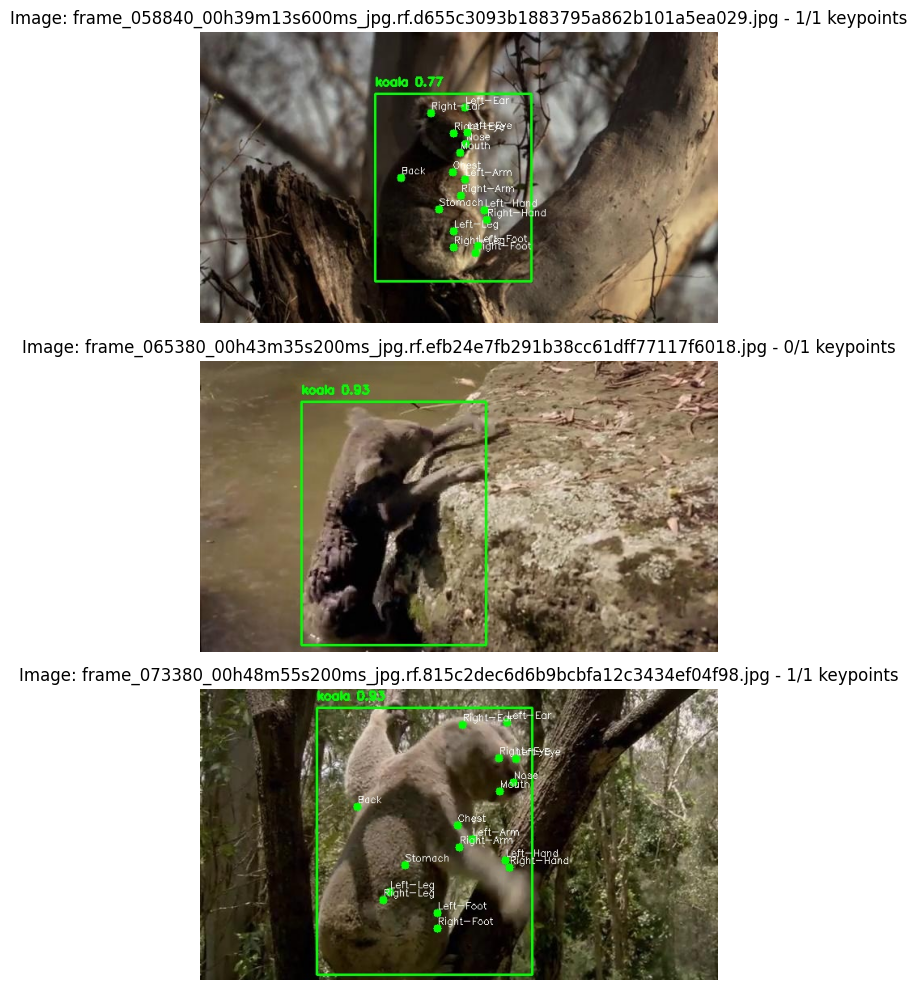


=== Testing Complete ===


In [11]:
#@title Unified Sequential Testing (Object Detection + Pose)

import glob
import os
import sys
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# Add the repository root to the Python path
REPO_ROOT = "/content/YoloV12-Object-Detection-Project"
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from scripts.unified_pose_model import UnifiedYOLO

# ============================
# CONFIGURATION SETTINGS
# ============================
# Choose which models to test
RUN_OBJECT_DETECTION = True
RUN_POSE_ESTIMATION = True
RUN_SEQUENTIAL = True  # Run object detection followed by pose estimation

# Path settings
OBJECT_DETECTION_MODEL = "/content/YoloV12-Object-Detection-Project/runs/completed-training/koala-anatomy-features/train1/features_train3_best.pt"  # Change to best object detection model
POSE_ESTIMATION_MODEL = "/content/YoloV12-Object-Detection-Project/runs/completed-training/train2/weights/best.pt"  # Change to best pose model

# Data configuration
POSE_DATA_YAML = "/content/YoloV12-Object-Detection-Project/yaml/data.yaml"
OBJECT_DATA_YAML = "/content/YoloV12-Object-Detection-Project/yaml/koala-anatomy-features.yaml"

# Output paths
RESULTS_DIR = "/content/YoloV12-Object-Detection-Project/runs/test-results"
MODEL_TEST_DIR = "/content/YoloV12-Object-Detection-Project/runs/test-models/validation"
SEQUENTIAL_TEST_DIR = "/content/YoloV12-Object-Detection-Project/runs/test-models/sequential"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_TEST_DIR, exist_ok=True)
os.makedirs(SEQUENTIAL_TEST_DIR, exist_ok=True)

# Choose which test set to use for sequential evaluation
TEST_SET_SOURCE = "both"  # Options: "pose", "object", or "both"(sequential)

# ============================
# HELPER FUNCTIONS
# ============================

def load_keypoint_names():
    """Load keypoint names from COCO JSON file"""
    keypoint_names = ["kpt"+str(i) for i in range(17)]  # Default names
    try:
        coco_path = "/content/YoloV12-Object-Detection-Project/datasets/koala/train/_annotations.coco.json"
        if os.path.exists(coco_path):
            with open(coco_path, 'r') as cf:
                coco_data = json.load(cf)
            for cat in coco_data.get('categories', []):
                if 'keypoints' in cat:
                    keypoint_names = cat['keypoints']
                    print(f"Found {len(keypoint_names)} keypoint names")
                    break
    except Exception as e:
        print(f"Could not load keypoint names: {e}")
    return keypoint_names

def sequential_prediction(object_model, pose_model, image_path, conf_threshold=0.25, iou_threshold=0.45):
    """Run object detection first, then pass detections to pose estimation"""
    # Run object detection
    obj_results = object_model.predict(
        source=image_path,
        conf=conf_threshold,
        iou=iou_threshold,
        augment=False,
        verbose=False
    )[0]

    # Get the original image
    img = cv2.imread(image_path)
    orig_img = img.copy()
    h, w = img.shape[:2]

    # Process each detection
    detections = []
    for i, box in enumerate(obj_results.boxes.xyxy.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        conf = float(obj_results.boxes.conf[i])
        cls = int(obj_results.boxes.cls[i])

        # Process all bounding boxes for visualization
        detection = {
            'bbox': [x1, y1, x2, y2],
            'conf': conf,
            'cls': cls
        }

        # Only run pose estimation on class 0 (whole koala)
        if cls == 0:  # Class index 0 is 'koala' (whole animal)
            # Crop the detection with some margin
            margin = 50  # Larger margin gives more context for pose estimation
            crop_x1 = max(0, x1 - margin)
            crop_y1 = max(0, y1 - margin)
            crop_x2 = min(w, x2 + margin)
            crop_y2 = min(h, y2 + margin)

            # Crop the image
            cropped_img = img[crop_y1:crop_y2, crop_x1:crop_x2]

            # Skip if crop is empty
            if cropped_img.size == 0:
                detections.append(detection)
                continue

            # Save cropped image temporarily
            crop_path = f"/tmp/crop_{i}.jpg"
            cv2.imwrite(crop_path, cropped_img)

            # Run pose estimation on the crop
            pose_results = pose_model.predict(
                source=crop_path,
                task="pose",
                conf=conf_threshold,
                augment=False,
                verbose=False
            )[0]

            # Process keypoints if any
            if (hasattr(pose_results, 'keypoints') and
                pose_results.keypoints is not None and
                len(pose_results.keypoints.data) > 0):

                keypoints = pose_results.keypoints.data[0].cpu().numpy()

                # Adjust keypoint coordinates to original image space
                if len(keypoints) > 0:
                    # Only adjust x,y coordinates (not confidence)
                    keypoints[:, 0] = keypoints[:, 0] + crop_x1
                    keypoints[:, 1] = keypoints[:, 1] + crop_y1

                    # Add keypoints to the detection
                    detection['keypoints'] = keypoints

            # Clean up
            if os.path.exists(crop_path):
                os.remove(crop_path)

        # Add the detection to our results
        detections.append(detection)

    return detections, orig_img

def visualize_sequential_results(img, detections, keypoint_names, save_path=None):
    """Visualize results from sequential detection"""
    # Colors for visualization
    colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

    # Class names from Object Detection YAML
    class_names = ['koala', 'koala_claws', 'koala_ears', 'koala_nose']

    # Draw each detection
    for i, det in enumerate(detections):
        # Draw bounding box
        x1, y1, x2, y2 = det['bbox']
        color = colors[i % len(colors)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Add class label and confidence
        cls_id = det['cls']
        cls_name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
        label = f"{cls_name} {det['conf']:.2f}"
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Draw keypoints only for class 0 (koala)
        if 'keypoints' in det and det['cls'] == 0:
            for j, kpt in enumerate(det['keypoints']):
                x, y, v = kpt
                if v > 0.5:  # Only draw visible keypoints
                    # Draw point
                    cv2.circle(img, (int(x), int(y)), 5, (0, 255, 0), -1)

                    # Add keypoint name
                    if j < len(keypoint_names):
                        name = keypoint_names[j]
                        cv2.putText(img, name, (int(x), int(y)-5),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    # Save the result
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, img)

    return img

# ============================
# MAIN TESTING CODE
# ============================

# Load keypoint names
keypoint_names = load_keypoint_names()

# Run tests on individual models first
if RUN_OBJECT_DETECTION:
    print("\n=== Testing Object Detection Model ===")
    try:
        obj_model = YOLO(OBJECT_DETECTION_MODEL)
        obj_metrics = obj_model.val(
            data=OBJECT_DATA_YAML,
            split="test",
            imgsz=960,
            batch=8,
            augment=False,
            project=MODEL_TEST_DIR,
            name="object_detection",
            exist_ok=True
        )

        # Save metrics
        save_path = os.path.join(RESULTS_DIR, "object_detection_metrics.txt")
        with open(save_path, "w") as f:
            f.write(f"Object Detection Model: {OBJECT_DETECTION_MODEL}\n\n")
            f.write("=== Overall Metrics ===\n")
            for k, v in obj_metrics.results_dict.items():
                f.write(f"{k}: {v}\n")

        print(f"Object detection metrics saved to {save_path}")
    except Exception as e:
        print(f"Error testing object detection model: {e}")

if RUN_POSE_ESTIMATION:
    print("\n=== Testing Pose Estimation Model ===")
    try:
        pose_model = UnifiedYOLO(model=POSE_ESTIMATION_MODEL, task="pose")
        pose_metrics = pose_model.val(
            data=POSE_DATA_YAML,
            split="test",
            imgsz=960,
            batch=8,
            augment=False,
            project=MODEL_TEST_DIR,
            name="pose_estimation",
            exist_ok=True
        )

        # Save metrics
        save_path = os.path.join(RESULTS_DIR, "pose_estimation_metrics.txt")
        with open(save_path, "w") as f:
            f.write(f"Pose Estimation Model: {POSE_ESTIMATION_MODEL}\n\n")
            f.write("=== Overall Metrics ===\n")
            for k, v in pose_metrics.results_dict.items():
                f.write(f"{k}: {v}\n")

            # Keypoint-specific metrics
            if hasattr(pose_metrics, 'kpt_ap') and pose_metrics.kpt_ap is not None:
                f.write("\n=== Keypoint-specific AP ===\n")
                for i, ap in enumerate(pose_metrics.kpt_ap):
                    kpt_name = keypoint_names[i] if i < len(keypoint_names) else f"kpt{i}"
                    f.write(f"{kpt_name}: {ap:.4f}\n")

        print(f"Pose estimation metrics saved to {save_path}")
    except Exception as e:
        print(f"Error testing pose estimation model: {e}")

# Run sequential test
if RUN_SEQUENTIAL and RUN_OBJECT_DETECTION and RUN_POSE_ESTIMATION:
    print("\n=== Testing Sequential Pipeline ===")

    # Load both models
    obj_model = YOLO(OBJECT_DETECTION_MODEL)
    pose_model = UnifiedYOLO(model=POSE_ESTIMATION_MODEL, task="pose")

    # Get test images based on selected source
    if TEST_SET_SOURCE == "pose":
        test_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/test"
        test_images = glob.glob(os.path.join(test_dir, "images/*.jpg"))
        if not test_images:  # Try without "images/" subfolder as fallback
            test_images = glob.glob(os.path.join(test_dir, "*.jpg"))
        print(f"Using pose estimation test set: {len(test_images)} images")

        if test_images:
            # Process a sample of test images
            sample_images = test_images[:5]  # Process first 5 images
            results = []

            for i, img_path in enumerate(sample_images):
                print(f"Processing test image {i+1}/{len(sample_images)}: {os.path.basename(img_path)}")

                # Run sequential prediction
                detections, orig_img = sequential_prediction(obj_model, pose_model, img_path)

                # Create visualization
                if detections:
                    viz_path = os.path.join(SEQUENTIAL_TEST_DIR, f"sequential_pose_{i}.jpg")
                    vis_img = visualize_sequential_results(orig_img.copy(), detections, keypoint_names, viz_path)

                    # Store results
                    results.append({
                        'image': os.path.basename(img_path),
                        'detections': len(detections),
                        'keypoints_found': sum(1 for d in detections if 'keypoints' in d),
                        'output': viz_path
                    })

            # Add summary code for pose case
            summary_path = os.path.join(RESULTS_DIR, "sequential_pipeline_pose_results.txt")
            with open(summary_path, "w") as f:
                f.write("Sequential Pipeline Test Results (Pose Test Set)\n")
                f.write(f"Object Detection Model: {OBJECT_DETECTION_MODEL}\n")
                f.write(f"Pose Estimation Model: {POSE_ESTIMATION_MODEL}\n\n")

                f.write("=== Results Summary ===\n")
                total_detections = sum(r['detections'] for r in results)
                total_with_keypoints = sum(r['keypoints_found'] for r in results)
                f.write(f"Images processed: {len(results)}\n")
                f.write(f"Total detections: {total_detections}\n")
                f.write(f"Detections with keypoints: {total_with_keypoints}\n")
                f.write(f"Success rate: {total_with_keypoints/max(1, total_detections):.2%}\n\n")

                f.write("=== Individual Results ===\n")
                for r in results:
                    f.write(f"Image: {r['image']}\n")
                    f.write(f"  Detections: {r['detections']}\n")
                    f.write(f"  With keypoints: {r['keypoints_found']}\n")
                    f.write(f"  Output: {r['output']}\n\n")

            print(f"Sequential pipeline results saved to {summary_path}")

    elif TEST_SET_SOURCE == "object":
        test_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala-features/test"
        test_images = glob.glob(os.path.join(test_dir, "images/*.jpg"))
        if not test_images:  # Try without "images/" subfolder as fallback
            test_images = glob.glob(os.path.join(test_dir, "*.jpg"))
        print(f"Using object detection test set: {len(test_images)} images")

        if test_images:
            # Process a sample of test images
            sample_images = test_images[:5]  # Process first 5 images
            results = []

            # Fixed indentation for the for loop
            for i, img_path in enumerate(sample_images):
                print(f"Processing test image {i+1}/{len(sample_images)}: {os.path.basename(img_path)}")

                # Run sequential prediction
                detections, orig_img = sequential_prediction(obj_model, pose_model, img_path)

                # Create visualization
                if detections:
                    viz_path = os.path.join(SEQUENTIAL_TEST_DIR, f"sequential_object_{i}.jpg")
                    vis_img = visualize_sequential_results(orig_img.copy(), detections, keypoint_names, viz_path)

                    # Store results
                    results.append({
                        'image': os.path.basename(img_path),
                        'detections': len(detections),
                        'keypoints_found': sum(1 for d in detections if 'keypoints' in d),
                        'output': viz_path
                    })

            # Add summary code for object case
            summary_path = os.path.join(RESULTS_DIR, "sequential_pipeline_object_results.txt")
            with open(summary_path, "w") as f:
                f.write("Sequential Pipeline Test Results (Object Test Set)\n")
                f.write(f"Object Detection Model: {OBJECT_DETECTION_MODEL}\n")
                f.write(f"Pose Estimation Model: {POSE_ESTIMATION_MODEL}\n\n")

                f.write("=== Results Summary ===\n")
                total_detections = sum(r['detections'] for r in results)
                total_with_keypoints = sum(r['keypoints_found'] for r in results)
                f.write(f"Images processed: {len(results)}\n")
                f.write(f"Total detections: {total_detections}\n")
                f.write(f"Detections with keypoints: {total_with_keypoints}\n")
                f.write(f"Success rate: {total_with_keypoints/max(1, total_detections):.2%}\n\n")

                f.write("=== Individual Results ===\n")
                for r in results:
                    f.write(f"Image: {r['image']}\n")
                    f.write(f"  Detections: {r['detections']}\n")
                    f.write(f"  With keypoints: {r['keypoints_found']}\n")
                    f.write(f"  Output: {r['output']}\n\n")

            print(f"Sequential pipeline results saved to {summary_path}")

    else:  # "both"
        # Process both test sets separately
        pose_test_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/test"
        obj_test_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala-features/test"

        pose_test_images = glob.glob(os.path.join(pose_test_dir, "images/*.jpg"))
        if not pose_test_images:  # Fallback
            pose_test_images = glob.glob(os.path.join(pose_test_dir, "*.jpg"))

        obj_test_images = glob.glob(os.path.join(obj_test_dir, "images/*.jpg"))
        if not obj_test_images:  # Fallback
            obj_test_images = glob.glob(os.path.join(obj_test_dir, "*.jpg"))

        # Create results container for both sets
        all_results = {}

        # Process each set separately
        for set_name, image_set in [("pose", pose_test_images[:5]), ("object", obj_test_images[:5])]:
            print(f"\n=== Processing {set_name} test set ({len(image_set)} images) ===")
            results = []

            for i, img_path in enumerate(image_set):
                print(f"Processing {set_name} image {i+1}/{len(image_set)}: {os.path.basename(img_path)}")

                # Run sequential prediction
                detections, orig_img = sequential_prediction(obj_model, pose_model, img_path)

                # Create visualization
                if detections:
                    viz_path = os.path.join(SEQUENTIAL_TEST_DIR, f"sequential_{set_name}_{i}.jpg")
                    vis_img = visualize_sequential_results(orig_img.copy(), detections, keypoint_names, viz_path)

                    # Store results
                    results.append({
                        'image': os.path.basename(img_path),
                        'detections': len(detections),
                        'keypoints_found': sum(1 for d in detections if 'keypoints' in d),
                        'output': viz_path
                    })

            # Store results for this set
            all_results[set_name] = results

        # Combine results for reporting
        combined_results = []
        for set_name, set_results in all_results.items():
            combined_results.extend(set_results)

        # Use combined results for the rest of the testing
        results = combined_results

        # Save summary
        summary_path = os.path.join(RESULTS_DIR, "sequential_pipeline_results.txt")
        with open(summary_path, "w") as f:
            f.write("Sequential Pipeline Test Results\n")
            f.write(f"Object Detection Model: {OBJECT_DETECTION_MODEL}\n")
            f.write(f"Pose Estimation Model: {POSE_ESTIMATION_MODEL}\n\n")

            f.write("=== Results Summary ===\n")
            total_detections = sum(r['detections'] for r in results)
            total_with_keypoints = sum(r['keypoints_found'] for r in results)
            f.write(f"Images processed: {len(results)}\n")
            f.write(f"Total detections: {total_detections}\n")
            f.write(f"Detections with keypoints: {total_with_keypoints}\n")
            f.write(f"Success rate: {total_with_keypoints/max(1, total_detections):.2%}\n\n")

            f.write("=== Individual Results ===\n")
            for r in results:
                f.write(f"Image: {r['image']}\n")
                f.write(f"  Detections: {r['detections']}\n")
                f.write(f"  With keypoints: {r['keypoints_found']}\n")
                f.write(f"  Output: {r['output']}\n\n")

        print(f"Sequential pipeline results saved to {summary_path}")

        # Display some results
        print("\n=== Sample Visualizations ===")
        fig, axes = plt.subplots(min(3, len(results)), 1, figsize=(10, 10))
        if len(results) == 1:
            axes = [axes]  # Make it iterable

        for i, r in enumerate(results[:3]):  # Show up to 3 results
            if os.path.exists(r['output']):
                img = cv2.imread(r['output'])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].set_title(f"Image: {r['image']} - {r['keypoints_found']}/{r['detections']} keypoints")
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()

print("\n=== Testing Complete ===")

## Step 7 — 🔮 Inference Testing For Images And Videos


After completeing a model test from step 6, we will move onto testing with new images and videos. Which can be sourced online anywhere. This way testing will be more accurate as its new data that the model hasn't been trained/tested on.

In [ ]:
#@title Create folder to store test images and videos **(skip this step if you already have these created previously from running the script)**

import os
from google.colab import files
import shutil

base_dir = "/content/YoloV12-Object-Detection-Project/testing"

# Uncomment the one you are not using
folder_name = "koala"
#folder_name = "kangaroo"

target_path = os.path.join(base_dir, folder_name)

os.makedirs(target_path, exist_ok=True)
print(f"Folder created at: {target_path}")

# Prompt user to upload files
print("Please upload your image or video files:")
uploaded = files.upload()

# Move uploaded files into the target folder
for filename in uploaded.keys():
    shutil.move(filename, os.path.join(target_path, filename))
    print(f"Moved '{filename}' to '{target_path}'.")

print("All files uploaded and saved in your custom directory!")

Folder created at: /content/YoloV12-Object-Detection-Project/testing/koala
Please upload your image or video files:


Saving frame_049320_00h32m52s800ms.jpg.jpg to frame_049320_00h32m52s800ms.jpg.jpg
Saving frame_049340_00h32m53s600ms.jpg.jpg to frame_049340_00h32m53s600ms.jpg.jpg
Saving frame_049380_00h32m55s200ms.jpg.jpg to frame_049380_00h32m55s200ms.jpg.jpg
Saving frame_049400_00h32m56s000ms.jpg.jpg to frame_049400_00h32m56s000ms.jpg.jpg
Saving frame_049440_00h32m57s600ms.jpg.jpg to frame_049440_00h32m57s600ms.jpg.jpg
Saving frame_049460_00h32m58s400ms.jpg.jpg to frame_049460_00h32m58s400ms.jpg.jpg
Saving frame_049480_00h32m59s200ms.jpg.jpg to frame_049480_00h32m59s200ms.jpg.jpg
Saving frame_049500_00h33m00s000ms.jpg.jpg to frame_049500_00h33m00s000ms.jpg.jpg
Saving frame_049520_00h33m00s800ms.jpg.jpg to frame_049520_00h33m00s800ms.jpg.jpg
Saving frame_049540_00h33m01s600ms.jpg.jpg to frame_049540_00h33m01s600ms.jpg.jpg
Saving frame_049580_00h33m03s200ms.jpg.jpg to frame_049580_00h33m03s200ms.jpg.jpg
Saving frame_049600_00h33m04s000ms.jpg.jpg to frame_049600_00h33m04s000ms.jpg.jpg
Saving frame_049

In [ ]:
#@title Inference Testing with Images & Videos

import glob
import os
from ultralytics import YOLO

# Add the repository root to the Python path
REPO_ROOT = "/content/YoloV12-Object-Detection-Project"
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from scripts.unified_pose_model import UnifiedYOLO

# Path where YOLO saves runs
RUNS_DIR = "/content/YoloV12-Object-Detection-Project/runs/completed-training"

# Uncomment the one you are not using
TEST_DIR = "/content/YoloV12-Object-Detection-Project/testing/koala"
#TEST_DIR = "/content/YoloV12-Object-Detection-Project/testing/kangaroo"

# Base path for inference results
OUTPUT_BASE = os.path.join(TEST_DIR, "inference_results")
os.makedirs(OUTPUT_BASE, exist_ok=True)

# Find the next available inference folder (inference1, inference2, ...)
i = 1
while os.path.exists(os.path.join(OUTPUT_BASE, f"inference{i}")):
    i += 1
OUTPUT_DIR = os.path.join(OUTPUT_BASE, f"inference{i}")

# Find the most recent training run
latest_run = max(glob.glob(os.path.join(RUNS_DIR, "*")), key=os.path.getmtime)
weights_path = os.path.join(latest_run, "weights", "best.pt")

print(f"Running inference with weights: {weights_path}")
print(f"Testing folder: {TEST_DIR}")
print(f"Results will be saved to: {OUTPUT_DIR}")

# Load model
model = UnifiedYOLO(weights_path)

# Run inference (images + videos in same folder)
#results = model.predict(
#    source=TEST_DIR,   # folder containing both images & videos
#    imgsz=1024,         # change between 540 960 1024 or more
#    conf=0.25,         # confidence higher means only detect if 0.70 or above (experiment to find the best conf)
#    save=True,
#    project=OUTPUT_DIR,
#    name="",           # ensures results are saved directly in OUTPUT_DIR
#    exist_ok=True
#)

# Run unified inference (pose included)
results = model.predict_unified(
    source=TEST_DIR,   # folder containing both images & videos
    imgsz=1024,         # change between 540 960 1024 or more
    conf=0.25,         # confidence higher means only detect if 0.70 or above (experiment to find the best conf)
    save=True,
    show=True,
    project=OUTPUT_DIR,
    name="",           # ensures results are saved directly in OUTPUT_DIR
    exist_ok=True
    )

# save machine-readable annotations
from pathlib import Path

label_dir = Path(OUTPUT_DIR) / "labels"
label_dir.mkdir(parents=True, exist_ok=True)

for r in results:
    # Make a file path using the original image name, but with .txt extension
    txt_path = label_dir / f"{Path(r.path).stem}.txt"
    r.save_txt(txt_path)        # give a full file path
    # For COCO format: r.save_json(label_dir / f"{Path(r.path).stem}.json")

# Save COCO keypoints instead of YOLO txt
"""
from pathlib import Path

label_dir = Path(OUTPUT_DIR) / "labels-coco"
label_dir.mkdir(parents=True, exist_ok=True)

for r in results:
    txt_path = label_dir / f"{Path(r.path).stem}.txt"
    r.save_json(label_dir)   # COCO-format keypoint annotations
"""
import json
from datetime import datetime

coco = {
    "info": {"year": datetime.now().year, "version": "1.0"},
    "licenses": [],
    "images": [],
    "annotations": [],
    "categories": [{
        "id": 1,
        "name": "koala",
        "keypoints": [
            "Left-Ear", "Right-Ear", "Nose", "Right-Eye", "Left-Eye",
            "Left-Arm", "Right-Arm", "Left-Leg", "Right-Leg", "Stomach",
            "Mouth", "Chest", "Back", "Right-Foot", "Left-Foot",
            "Left-Hand", "Right-Hand"
        ],
        "skeleton": []
    }]
}

ann_id = 1
img_id = 1

for r in results:
    file_name = Path(r.path).name
    w, h = r.orig_shape[1], r.orig_shape[0]

    coco["images"].append({
        "id": img_id, "file_name": file_name,
        "width": w, "height": h
    })

    for kp in r.keypoints.data.cpu().numpy():
        # flatten (x,y,visibility) triples
        kps = []
        for x, y, v in kp:
            kps.extend([float(x), float(y), int(v)])
        coco["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": 1,
            "keypoints": kps,
            "num_keypoints": int((len(kps))/3)
        })
        ann_id += 1
    img_id += 1

with open("coco_keypoints.json", "w") as f:
    json.dump(coco, f)

print(f"Inference complete. Results saved to: {OUTPUT_DIR}")


Running inference with weights: /content/YoloV12-Object-Detection-Project/runs/completed-training/train6/weights/best.pt
Testing folder: /content/YoloV12-Object-Detection-Project/testing/koala
Results will be saved to: /content/YoloV12-Object-Detection-Project/testing/koala/inference_results/inference9

image 1/200 /content/YoloV12-Object-Detection-Project/testing/koala/frame_049320_00h32m52s800ms.jpg.jpg: 576x1024 1 Koala, 1108.4ms
image 2/200 /content/YoloV12-Object-Detection-Project/testing/koala/frame_049340_00h32m53s600ms.jpg.jpg: 576x1024 1 Koala, 959.6ms
image 3/200 /content/YoloV12-Object-Detection-Project/testing/koala/frame_049380_00h32m55s200ms.jpg.jpg: 576x1024 1 Koala, 956.9ms
image 4/200 /content/YoloV12-Object-Detection-Project/testing/koala/frame_049400_00h32m56s000ms.jpg.jpg: 576x1024 1 Koala, 988.7ms
image 5/200 /content/YoloV12-Object-Detection-Project/testing/koala/frame_049440_00h32m57s600ms.jpg.jpg: 576x1024 1 Koala, 978.1ms
image 6/200 /content/YoloV12-Object-Det

# Step 8 - 🪣 Choosing Final Model for Deployment

This step will go through every single trained model/validation results, and finds/selects the best model from the metrics provided. This way with the Final Model selected will go through final inference testing then Step 9 to be exported and used in real world deployment.

In [ ]:
#@title Find the best final model to use from test results (saves as a csv)

import glob
import os
import pandas as pd

# Paths
TEST_RESULTS_DIR = "/content/YoloV12-Object-Detection-Project/runs/test-results"
RESULTS_DIR = "/content/YoloV12-Object-Detection-Project/runs/model-results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Output CSV path
CSV_PATH = os.path.join(RESULTS_DIR, "model_comparison.csv")

rows = []

for path in sorted(glob.glob(os.path.join(TEST_RESULTS_DIR, "*_metrics.txt"))):
    with open(path, "r") as f:
        lines = [ln.strip() for ln in f.readlines()]

    # Defaults
    run = ""
    weights = ""
    precision = recall = map50 = map5095 = fitness = None

    for ln in lines:
        if ln.startswith("Validation results for run:"):
            run = ln.split("Validation results for run:", 1)[1].strip()
        elif ln.startswith("Weights:"):
            weights = ln.split("Weights:", 1)[1].strip()
        elif ln.startswith("metrics/precision(B):"):
            precision = float(ln.split(":", 1)[1].strip())
        elif ln.startswith("metrics/recall(B):"):
            recall = float(ln.split(":", 1)[1].strip())
        elif ln.startswith("metrics/mAP50(B):"):
            map50 = float(ln.split(":", 1)[1].strip())
        elif ln.startswith("metrics/mAP50-95(B):"):
            map5095 = float(ln.split(":", 1)[1].strip())
        elif ln.startswith("fitness:"):
            fitness = float(ln.split(":", 1)[1].strip())

    if run and weights:
        rows.append({
            "run": run,
            "weights": weights,
            "mAP50": map50,
            "mAP50-95": map5095,
            "precision": precision,
            "recall": recall,
            "fitness": fitness,
            "metrics_file": os.path.basename(path),
        })

# Save results to CSV
df = pd.DataFrame(rows)
df.to_csv(CSV_PATH, index=False)

print(f"\nModel comparison saved to {CSV_PATH}")
print(df)




In [ ]:
#@title Compares Model Metrics in CSV and chooses the best model

import os
import shutil
import pandas as pd

# ==== CONFIG ====
CSV_PATH = "/content/YoloV12-Object-Detection-Project/runs/model-results/model_comparison.csv"
MODELS_DIR = "/content/YoloV12-Object-Detection-Project/models"
SUMMARY_DIR = "/content/YoloV12-Object-Detection-Project/runs/model-results/comparison"  # fixed path

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SUMMARY_DIR, exist_ok=True)

# loads csv file
df = pd.read_csv(CSV_PATH)

# checks csv columns (correct data)
required_cols = {"run", "weights", "mAP50-95", "mAP50", "precision", "recall"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")

for c in ["mAP50-95", "mAP50", "precision", "recall"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# picks best model from csv data metrics
best_row = df.sort_values(
    by=["mAP50-95", "mAP50", "precision"],  # tie-break if needed
    ascending=[False, False, False]
).iloc[0]

run = best_row["run"]
src = best_row["weights"]

if not isinstance(src, str) or not os.path.exists(src):
    raise FileNotFoundError(f"best.pt not found: {src}")

# Destination name: trainxxx_best.pt
base_name = f"{run}_best.pt"
dst = os.path.join(MODELS_DIR, base_name)

print(f"   Best model found: {run}")
print(f"   mAP50-95: {best_row['mAP50-95']:.4f} | mAP50: {best_row['mAP50']:.4f} | precision: {best_row['precision']:.4f}")
print(f"   Copying: {src} -> {dst}")

shutil.copy2(src, dst)

# Output and saving summary selection
summary_csv = os.path.join(SUMMARY_DIR, "best_model_summary.csv")
best_row.to_frame().T.to_csv(summary_csv, index=False)
print(f"\n Summary written to: {summary_csv}")




# Step 9 — ♟️ Exporting

For step 9, users will export the best model for deployment and aslo export the respository to be saved.

## 9.1 - ⏹️ Export the model to deployment ready onnx file

The script below will run and export the best model chosen and convert it to an ONNX file which can be used for deployment and running on software.

In [ ]:
#@title Export our best trained model to ONNX File Format

from ultralytics import YOLO
from scripts.unified_pose_model import UnifiedYOLO
import os, shutil

# Edit Path to your best selected model
PT_PATH = "/content/YoloV12-Object-Detection-Project/runs/completed-training/train2/weights/best.pt"
EXPORT_PATH = "/content/YoloV12-Object-Detection-Project/runs/final-models-exports/train2_best.onnx"


# Ensure export directory exists
os.makedirs(os.path.dirname(EXPORT_PATH), exist_ok=True)

# Load model
model = YOLO(PT_PATH)

# Export to ONNX (Ultralytics will create it in a temp folder) (set the correct config from your models)
onnx_tmp_path = model.export(format="onnx", dynamic=True, imgsz=960)

# Move/rename to your chosen path
if os.path.exists(EXPORT_PATH):
    os.remove(EXPORT_PATH)
shutil.move(onnx_tmp_path, EXPORT_PATH)

print(f"ONNX saved to: {EXPORT_PATH}")


## 9.2 🔽-  Exporting Repository to zip file (locally and google drive)

You can use this step to export your repository to save your work or when you have completed full training

In [13]:
#@title Export Repository as Zip File (downloads locally to host machine)
import shutil

shutil.make_archive('YoloV12-Object-Detection-Project', 'zip', '/content/YoloV12-Object-Detection-Project')

from google.colab import files
files.download('YoloV12-Object-Detection-Project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
#@title Export Repository as Zip File To Google Drive (downloads to google drive cloud)

from google.colab import drive
import shutil
import os

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define source folder (local) and destination zip path (Drive)
source_folder = '/content/YoloV12-Object-Detection-Project'  # local folder to zip
zip_name = 'YoloV12-Object-Detection-Project.zip'
zip_local_path = f'/content/{zip_name}'
drive_destination = f'/content/drive/MyDrive/{zip_name}'  # overwrite on Drive

# Step 3: Zip the source folder
if os.path.exists(zip_local_path):
    os.remove(zip_local_path)  # remove old local zip if exists
shutil.make_archive(base_name=zip_local_path.replace('.zip', ''), format='zip', root_dir=source_folder)
print(f"Zipped folder: {zip_local_path}")

# Step 4: Copy zip to Google Drive (overwrite if exists)
if os.path.exists(drive_destination):
    os.remove(drive_destination)
shutil.copy2(zip_local_path, drive_destination)
print(f"Copied {zip_local_path} to {drive_destination}")

# Step 5: Unmount Google Drive and clean up
drive.flush_and_unmount()
shutil.rmtree('/content/drive', ignore_errors=True)
print("Google Drive unmounted and cleaned up.")

Mounted at /content/drive
Zipped folder: /content/YoloV12-Object-Detection-Project.zip
Copied /content/YoloV12-Object-Detection-Project.zip to /content/drive/MyDrive/YoloV12-Object-Detection-Project.zip
Google Drive unmounted and cleaned up.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Troubleshooting


image 1/1 /content/YoloV12-Object-Detection-Project/datasets/koala/test/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg: 544x960 1 Koala, 984.5ms
Speed: 16.5ms preprocess, 984.5ms inference, 1.6ms postprocess per image at shape (1, 3, 544, 960)
Results saved to /content/YoloV12-Object-Detection-Project/inference_debug/pose_check


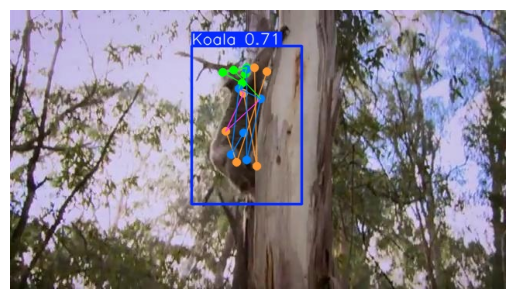

Saved annotated image to: /content/YoloV12-Object-Detection-Project/inference_debug/pose_check/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg


In [ ]:
#@title Debug - Infer/Check Keypoint Presence
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import torch
import os

# --- Paths ---
MODEL_PATH = "/content/YoloV12-Object-Detection-Project/runs/completed-training/train10/weights/best.pt"
TEST_IMAGE = "/content/YoloV12-Object-Detection-Project/datasets/koala/test/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg"  # <-- replace with any image
SAVE_DIR   = "/content/YoloV12-Object-Detection-Project/inference_debug"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Load model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO(MODEL_PATH).to(device)

# --- Run inference ---
# 'task="pose"' forces the model to look for keypoints if present
results = model.predict(
    source=TEST_IMAGE,
    task="pose",
    imgsz=960,
    conf=0.25,
    save=True,            # saves annotated images to SAVE_DIR
    project=SAVE_DIR,
    name="pose_check",
    exist_ok=True
)

# Optional: Display the first annotated image inside the notebook
out_path = os.path.join(SAVE_DIR, "pose_check", os.path.basename(TEST_IMAGE))
img = cv2.cvtColor(cv2.imread(out_path), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

print("Saved annotated image to:", out_path)


Found 17 keypoint names: ['Left-Ear', 'Right-Ear', 'Nose', 'Right-Eye', 'Left-Eye', 'Left-Arm', 'Right-Arm', 'Left-Leg', 'Right-Leg', 'Stomach', 'Mouth', 'Chest', 'Back', 'Right-Foot', 'Left-Foot', 'Left-Hand', 'Right-Hand']

image 1/1 /content/YoloV12-Object-Detection-Project/datasets/koala/test/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg: 544x960 1 Koala, 688.2ms
Speed: 6.1ms preprocess, 688.2ms inference, 1.7ms postprocess per image at shape (1, 3, 544, 960)
Results saved to /content/YoloV12-Object-Detection-Project/inference_debug/pose_check


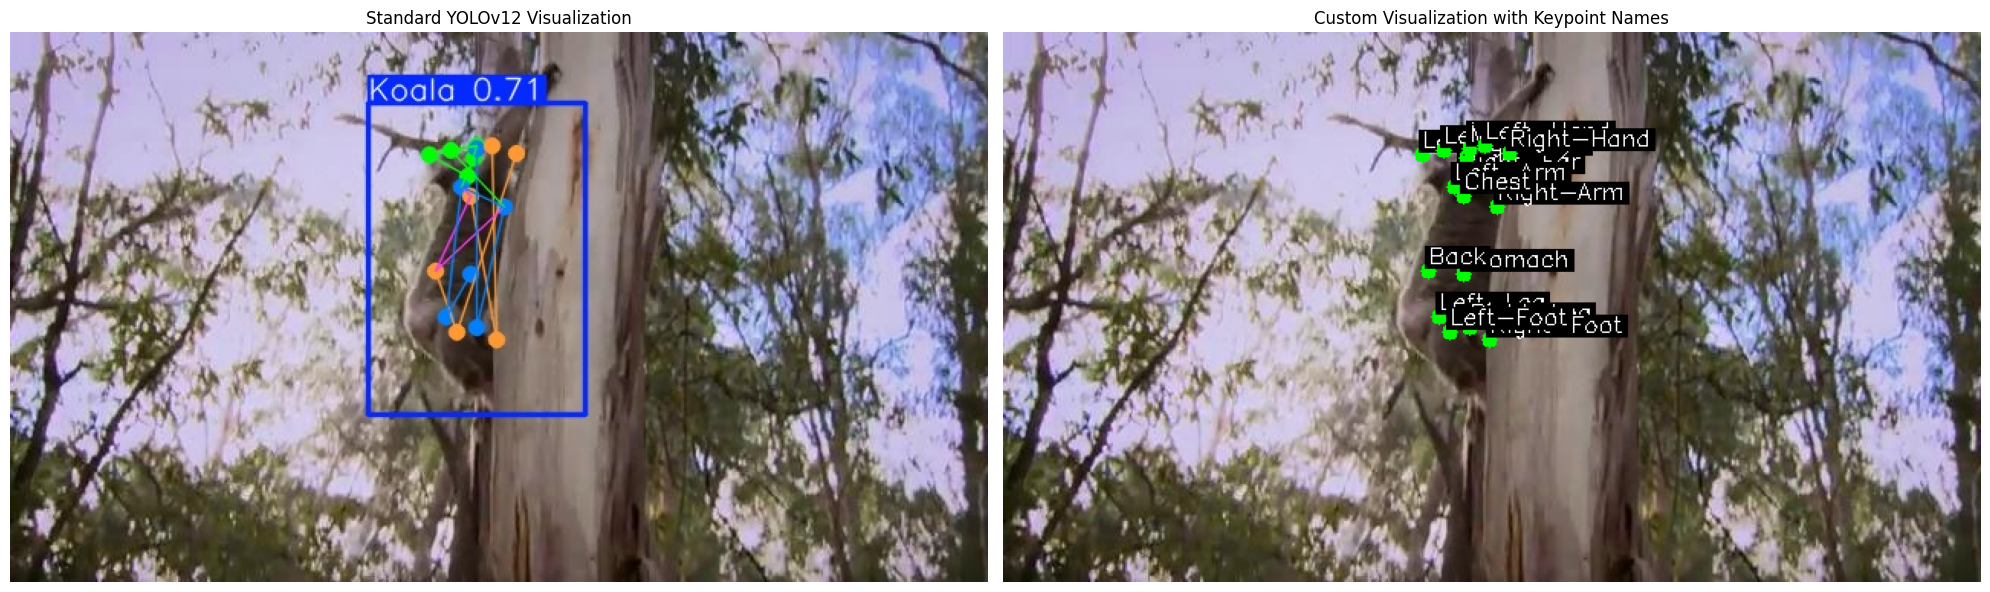

Saved standard visualization to: /content/YoloV12-Object-Detection-Project/inference_debug/pose_check/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg
Saved custom visualization with keypoint names to: /content/YoloV12-Object-Detection-Project/inference_debug/named_keypoints/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg


In [ ]:
#@title Debug - Infer with Named Keypoints
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import torch
import os
import json
import numpy as np

# --- Paths ---
MODEL_PATH = "/content/YoloV12-Object-Detection-Project/runs/completed-training/train10/weights/best.pt"
TEST_IMAGE = "/content/YoloV12-Object-Detection-Project/datasets/koala/test/frame_055980_00h37m19s200ms_jpg.rf.df470fa7b287418ff2c99d29e3a1b7b3.jpg"
SAVE_DIR = "/content/YoloV12-Object-Detection-Project/inference_debug"
COCO_JSON = "/content/YoloV12-Object-Detection-Project/datasets/koala/train/_annotations.coco.json"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Load model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO(MODEL_PATH).to(device)

# --- Extract keypoint names from COCO JSON ---
keypoint_names = []
try:
    with open(COCO_JSON, 'r') as f:
        coco_data = json.load(f)

    # Find keypoint names in categories
    for cat in coco_data.get('categories', []):
        if 'keypoints' in cat and cat['keypoints']:
            keypoint_names = cat['keypoints']
            print(f"Found {len(keypoint_names)} keypoint names: {keypoint_names}")
            break
except Exception as e:
    print(f"Error loading keypoint names: {e}")
    # Fallback to generic names
    keypoint_names = [f"kpt{i}" for i in range(17)]

# --- Run inference ---
# Standard prediction first (for comparison)
results = model.predict(
    source=TEST_IMAGE,
    task="pose",
    imgsz=960,
    conf=0.25,
    save=True,
    project=SAVE_DIR,
    name="pose_check",
    exist_ok=True
)

# --- Create custom visualization with keypoint names ---
def visualize_with_names(image_path, results, keypoint_names, output_path):
    # Load image
    img = cv2.imread(image_path)

    # Process each detection
    for i, result in enumerate(results):
        # Get keypoints if available
        if hasattr(result, 'keypoints') and result.keypoints is not None:
            keypoints = result.keypoints.data.cpu().numpy()

            # For each instance detected
            for kpts in keypoints:
                # Draw each keypoint with its name
                for j, kpt in enumerate(kpts):
                    # Only process valid keypoints
                    if j >= len(keypoint_names) or kpt[2] < 0.5:  # visibility threshold
                        continue

                    # Get coordinates and name
                    x, y = int(kpt[0]), int(kpt[1])
                    name = keypoint_names[j]

                    # Draw point
                    cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

                    # Draw name with background for better visibility
                    text_size = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
                    cv2.rectangle(img,
                                 (x - 2, y - text_size[1] - 4),
                                 (x + text_size[0] + 2, y - 2),
                                 (0, 0, 0), -1)
                    cv2.putText(img, name, (x, y - 5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Save the annotated image
    cv2.imwrite(output_path, img)
    return img

# Create custom visualization
custom_output = os.path.join(SAVE_DIR, "named_keypoints", os.path.basename(TEST_IMAGE))
os.makedirs(os.path.dirname(custom_output), exist_ok=True)
custom_img = visualize_with_names(TEST_IMAGE, results, keypoint_names, custom_output)

# Display both versions
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Original YOLOv12 visualization
out_path = os.path.join(SAVE_DIR, "pose_check", os.path.basename(TEST_IMAGE))
orig_img = cv2.cvtColor(cv2.imread(out_path), cv2.COLOR_BGR2RGB)
axes[0].imshow(orig_img)
axes[0].set_title("Standard YOLOv12 Visualization")
axes[0].axis("off")

# Custom visualization with names
axes[1].imshow(cv2.cvtColor(custom_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Custom Visualization with Keypoint Names")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Saved standard visualization to:", out_path)
print("Saved custom visualization with keypoint names to:", custom_output)

In [ ]:
#@title Debug Check - Inspect Confidence for Keypoints
from ultralytics import YOLO
model = YOLO("/content/YoloV12-Object-Detection-Project/runs/completed-training/train10/weights/best.pt")  # adjust
res = model.predict(source="/content/YoloV12-Object-Detection-Project/datasets/koala/valid/images/frame_049600_00h33m04s000ms_jpg.rf.55e155ac2213dc7de94c2bdd96e98295.jpg", task="pose", imgsz=960, conf=0.0)
r = res[0]
print("Boxes:", r.boxes.xyxy if hasattr(r, 'boxes') else None)
# keypoints: depends on ultralytics version; try:
try:
    kpts = r.keypoints  # sometimes available
    print("Keypoints:", kpts)
except Exception as e:
    # fallback: parse raw
    print("result object keys:", dir(r))
# print confidences for keypoints if present:
if hasattr(r, 'keypoints') and len(r.keypoints) > 0:
    print("Keypoints array shape:", r.keypoints.xy.shape if hasattr(r.keypoints, 'xy') else None)
#If confidences are extremely low, they will be filtered by validation


image 1/1 /content/YoloV12-Object-Detection-Project/datasets/koala/valid/images/frame_049600_00h33m04s000ms_jpg.rf.55e155ac2213dc7de94c2bdd96e98295.jpg: 544x960 300 Koalas, 1002.9ms
Speed: 47.0ms preprocess, 1002.9ms inference, 788.0ms postprocess per image at shape (1, 3, 544, 960)
Boxes: tensor([[1.2688e+02, 1.2824e+01, 4.7743e+02, 3.6000e+02],
        [2.8819e-02, 1.1255e+01, 4.4735e+01, 3.6000e+02],
        [0.0000e+00, 6.2388e+00, 6.5958e+01, 3.6000e+02],
        ...,
        [0.0000e+00, 0.0000e+00, 1.2253e+02, 2.6292e+01],
        [3.0759e+02, 2.9764e+02, 4.3119e+02, 3.6000e+02],
        [3.3351e-02, 0.0000e+00, 3.9954e+01, 1.9031e+02]])
Keypoints: ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9598, 0.9716, 0.9919,  ..., 0.7750, 0.9324, 0.9343],
        [0.0161, 0.0153, 0.0055,  ..., 0.0432, 0.0527, 0.0600],
        [0.0150, 0.0108, 0.0046,  ..., 0.0386, 0.0505, 0.0537],
        ...,
        [0.0518, 0.0461, 0.0427,  ..., 0.1083, 0.0949, 0.0910]


- **Weights YAML missing:** ensure `models/yolo12s.pt` and `yaml/data.yaml` exist in the repo or update paths.
- **Val fails:** Train first; then rerun the validate cell.
- **Poor metrics:** Add more data, correct labels, tune `imgsz`/`batch`/`epochs`.


In [ ]:
#@title Debug Check - Count Keypoints
import os, glob
from pathlib import Path

labels_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/valid/labels"  # adjust
txts = glob.glob(os.path.join(labels_dir, "*.txt"))
count_with_kpts = 0
total = len(txts)
for t in txts:
    s = open(t).read().strip()
    if not s:
        continue
    # YOLOv8 keypoints txt format typically: class x y w h x1 y1 v1 x2 y2 v2 ...
    if len(s.split()) > 5:  # more than bbox fields
        count_with_kpts += 1
print(f"{count_with_kpts}/{total} label files contain extra fields (likely keypoints).")

40/40 label files contain extra fields (likely keypoints).


Image: /content/YoloV12-Object-Detection-Project/datasets/koala/valid/images/frame_059080_00h39m23s200ms_jpg.rf.46f869fdfbdaefffb099adc3a8d5770a.jpg
Label file: /content/YoloV12-Object-Detection-Project/datasets/koala/valid/labels/frame_059080_00h39m23s200ms_jpg.rf.46f869fdfbdaefffb099adc3a8d5770a.txt
First 50 tokens: ['0', '0.6266818749999999', '0.46338333333333337', '0.2158653125', '0.4336055555555556', '0.610386875', '0.2823611111111111', '1', '0.61057625', '0.29202805555555555', '2', '0.64617484375', '0.3240841666666667', '2', '0.64230703125', '0.31596722222222223', '2', '0.64519171875', '0.3091275', '1', '0.6487271875', '0.4202680555555556', '2', '0.656384375', '0.37692333333333333', '2', '0.60301046875', '0.5349091666666667', '2', '0.5634453125000001', '0.5425416666666667', '2', '0.60634734375', '0.46536805555555555', '2', '0.6468709375', '0.3348172222222222', '1', '0.613974375', '0.4000675', '1', '0.54373265625', '0.4228383333333333', '2', '0.5906165624999999', '0.60105777777777

(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

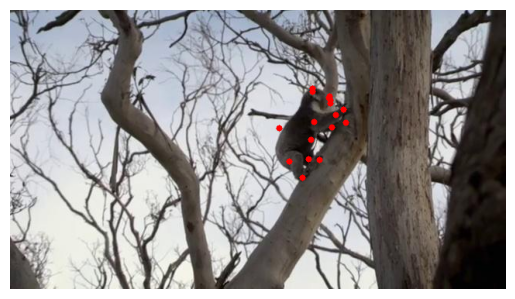

In [ ]:
#@title Debug Check - Visualated annotated keypoints
import cv2, matplotlib.pyplot as plt, numpy as np
img_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/valid/images"
labels_dir = "/content/YoloV12-Object-Detection-Project/datasets/koala/valid/labels"
example = sorted([p for p in Path(img_dir).glob("*")])[5]  # pick first image
img = cv2.cvtColor(cv2.imread(str(example)), cv2.COLOR_BGR2RGB)
lab = Path(labels_dir) / (example.stem + ".txt")
print("Image:", example)
print("Label file:", lab)
txt = lab.read_text().strip().split()
print("First 50 tokens:", txt[:50])

# parse first object
tokens = list(map(float, txt))
# YOLO normally: cls, x_center, y_center, w, h, then kpt triplets:
cls = int(tokens[0]); xc, yc, w, h = tokens[1:5]
kpt = tokens[5:]
kpt = np.array(kpt).reshape(-1,3)  # [N,3]: x,y,vis (normalized coords)
H, W = img.shape[:2]
for x,y,v in kpt:
    if v >= 0:  # or v>0 depends on your format
        px, py = int(x*W), int(y*H)
        cv2.circle(img, (px,py), 4, (255,0,0), -1)
plt.imshow(img); plt.axis('off')
#If the labels look off compared to the template, there's a problem with the label format
